# Procesamiento Digital y Segmentación de Imágenes de Células Sanguíneas con OpenCV

###  Descripción de la Actividad
Este cuaderno desarrolla un caso de uso de alto impacto para el sector de la salud y la bioingeniería. Utilizando la librería **OpenCV**, se diseña un entorno de Visión por Computadora clásica enfocado en el procesamiento digital, aislamiento y segmentación de estructuras celulares específicas (eritrocitos y basófilos) a partir de frotis sanguíneos.

###  Inferencias y Conclusiones Técnicas
* **Manipulación en Espacios de Color:** El flujo demuestra un dominio sólido en la descomposición de canales cromáticos y la aplicación de máscaras binarias automatizadas mediante umbralización adaptativa (`cv2.threshold`).
* **Ingeniería de Características Clínicas:** Al aislar la morfología celular mediante operaciones morfológicas, el cuaderno establece las bases analíticas para transformar píxeles de imágenes médicas en descriptores cuantitativos (área, contornos, excentricidad), esenciales para sistemas de asistencia al diagnóstico médico.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import cv2 # OPEN CV OPEN COMPUTER VISION
from google.colab.patches import cv2_imshow

In [ ]:
basofilos = files.upload()
erito = files.upload()

Saving BA_4118.jpg to BA_4118.jpg
Saving BA_6162.jpg to BA_6162.jpg
Saving BA_8742.jpg to BA_8742.jpg
Saving BA_18821.jpg to BA_18821.jpg
Saving BA_24720.jpg to BA_24720.jpg
Saving BA_25245.jpg to BA_25245.jpg
Saving BA_27810.jpg to BA_27810.jpg
Saving BA_28660.jpg to BA_28660.jpg
Saving BA_38346.jpg to BA_38346.jpg
Saving BA_42246.jpg to BA_42246.jpg
Saving BA_58432.jpg to BA_58432.jpg
Saving BA_59580.jpg to BA_59580.jpg
Saving BA_66887.jpg to BA_66887.jpg
Saving BA_68896.jpg to BA_68896.jpg
Saving BA_90355.jpg to BA_90355.jpg
Saving BA_93147.jpg to BA_93147.jpg
Saving BA_99338.jpg to BA_99338.jpg
Saving BA_121897.jpg to BA_121897.jpg
Saving BA_126839.jpg to BA_126839.jpg
Saving BA_155436.jpg to BA_155436.jpg
Saving BA_158249.jpg to BA_158249.jpg
Saving BA_174705.jpg to BA_174705.jpg
Saving BA_201200.jpg to BA_201200.jpg
Saving BA_229935.jpg to BA_229935.jpg
Saving BA_238012.jpg to BA_238012.jpg
Saving BA_254321.jpg to BA_254321.jpg
Saving BA_260100.jpg to BA_260100.jpg
Saving BA_2730

Saving ERB_32413.jpg to ERB_32413.jpg
Saving ERB_65895.jpg to ERB_65895.jpg
Saving ERB_92771.jpg to ERB_92771.jpg
Saving ERB_95333.jpg to ERB_95333.jpg
Saving ERB_104607.jpg to ERB_104607.jpg
Saving ERB_113277.jpg to ERB_113277.jpg
Saving ERB_113770.jpg to ERB_113770.jpg
Saving ERB_125603.jpg to ERB_125603.jpg
Saving ERB_141589.jpg to ERB_141589.jpg
Saving ERB_156600.jpg to ERB_156600.jpg
Saving ERB_167870.jpg to ERB_167870.jpg
Saving ERB_183171.jpg to ERB_183171.jpg
Saving ERB_199408.jpg to ERB_199408.jpg
Saving ERB_210322.jpg to ERB_210322.jpg
Saving ERB_215260.jpg to ERB_215260.jpg
Saving ERB_222938.jpg to ERB_222938.jpg
Saving ERB_243400.jpg to ERB_243400.jpg
Saving ERB_248999.jpg to ERB_248999.jpg
Saving ERB_308205.jpg to ERB_308205.jpg
Saving ERB_309282.jpg to ERB_309282.jpg
Saving ERB_328518.jpg to ERB_328518.jpg
Saving ERB_345085.jpg to ERB_345085.jpg
Saving ERB_351346.jpg to ERB_351346.jpg
Saving ERB_372346.jpg to ERB_372346.jpg
Saving ERB_384659.jpg to ERB_384659.jpg
Saving E

In [ ]:
!pwd

/content


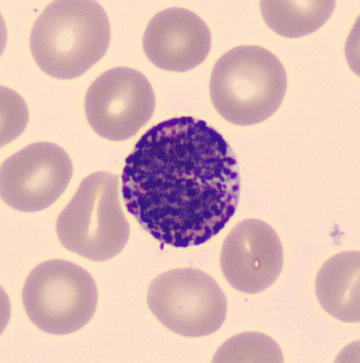

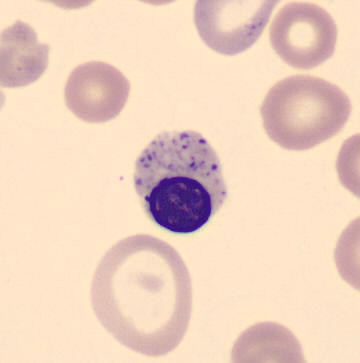

In [ ]:
baso0 = cv2.imread(list(basofilos.keys())[0])
eri0 = cv2.imread(list(erito.keys())[0])
cv2_imshow(baso0)
cv2_imshow(eri0)

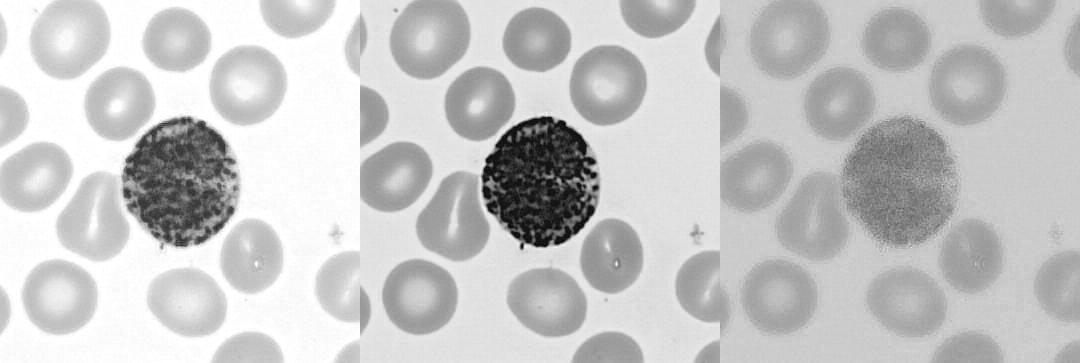

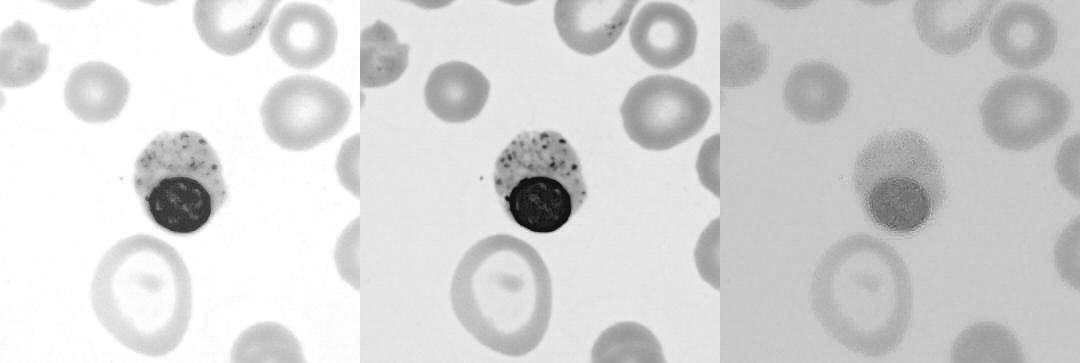

In [ ]:
# Transformamos la primera imagen de los basofilos y eritoblasto a RGB y extraemos las capas
Baso_rgb = cv2.cvtColor(baso0,cv2.COLOR_BGR2RGB)
Eri_rgb = cv2.cvtColor(eri0,cv2.COLOR_BGR2RGB)

C1_baso = Baso_rgb[:,:,0]
C2_baso = Baso_rgb[:,:,1]
C3_baso = Baso_rgb[:,:,2]

C1_eri = Eri_rgb[:,:,0]
C2_eri = Eri_rgb[:,:,1]
C3_eri = Eri_rgb[:,:,2]

cv2_imshow(np.hstack([C1_baso,C2_baso,C3_baso]))
cv2_imshow(np.hstack([C1_eri,C2_eri,C3_eri]))

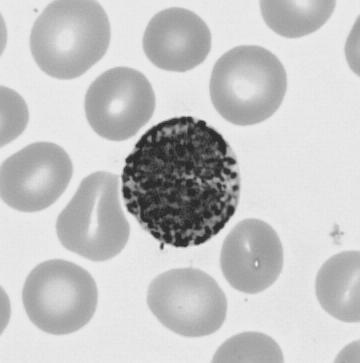

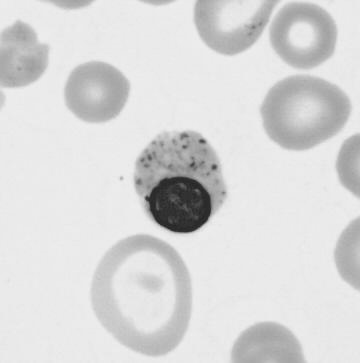

In [ ]:
# Convertimos a escala de grises
IEG_baso0 = cv2.cvtColor(baso0,cv2.COLOR_BGR2GRAY)
IEG_eri0 = cv2.cvtColor(eri0,cv2.COLOR_BGR2GRAY)

cv2_imshow(IEG_baso0)
cv2_imshow(IEG_eri0)

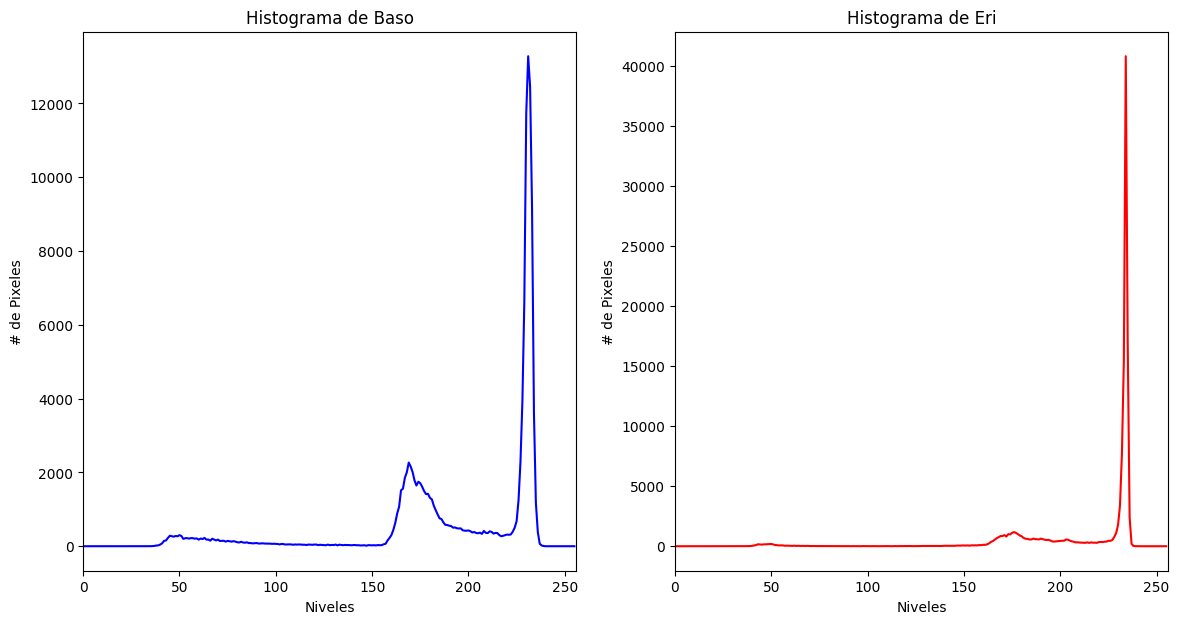

In [ ]:
# Dibujamos el histograma de ambas imagenes en escala de grises

hist_baso = cv2.calcHist([IEG_baso0],[0],None,[256],[0,256])

hist_eri = cv2.calcHist([IEG_eri0],[0],None,[256],[0,256])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))  # 1 fila, 2 columnas

# Dibujamos el primer histograma en el subplot izquierdo
axes[0].plot(hist_baso, color='b')
axes[0].set_title('Histograma de Baso')
axes[0].set_xlabel('Niveles')
axes[0].set_ylabel('# de Pixeles')
axes[0].set_xlim([0, 256])

# Dibujamos el segundo histograma en el subplot derecho
axes[1].plot(hist_eri, color='r')
axes[1].set_title('Histograma de Eri')
axes[1].set_xlabel('Niveles')
axes[1].set_ylabel('# de Pixeles')
axes[1].set_xlim([0, 256])

plt.show()

100.0


<Figure size 640x480 with 0 Axes>

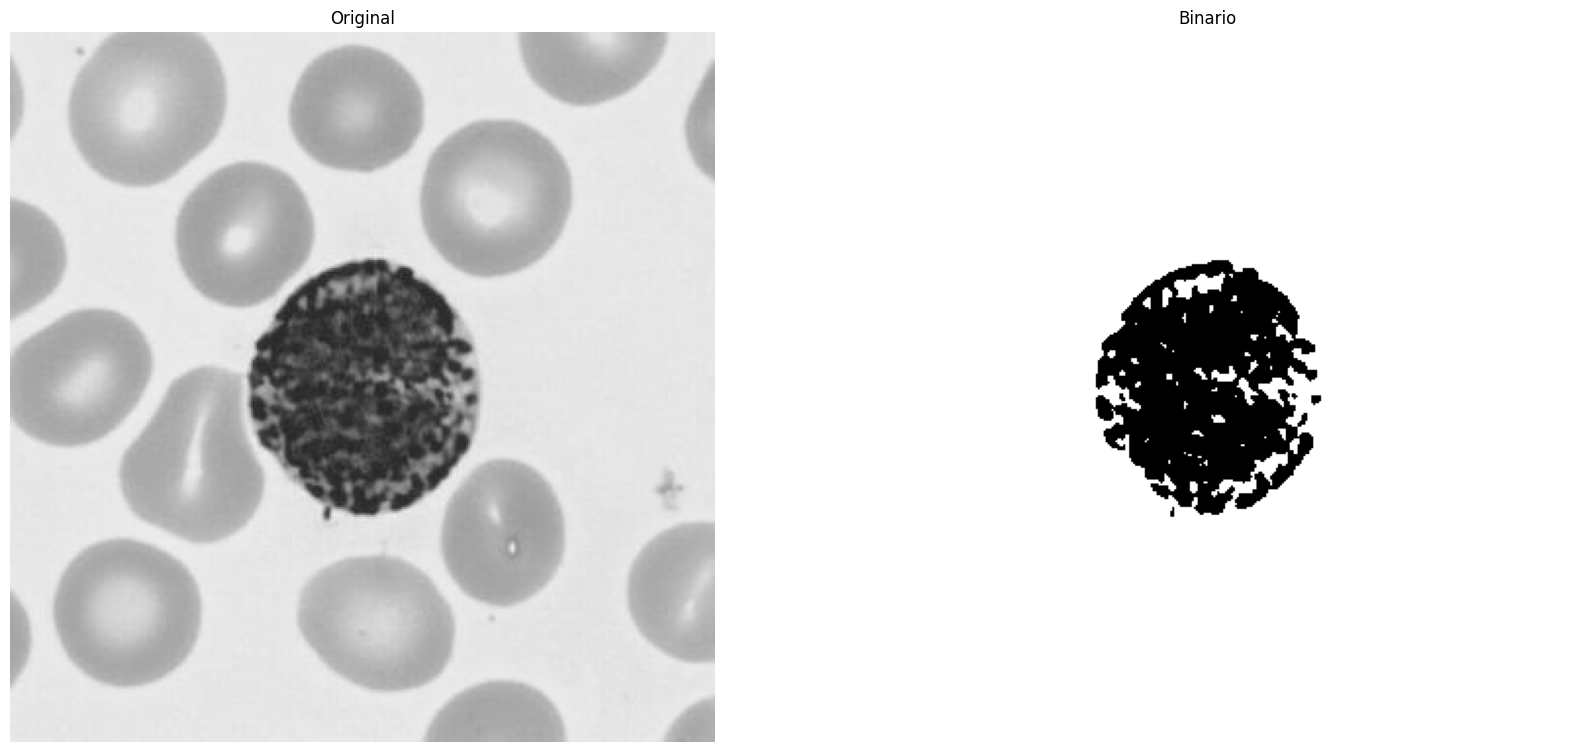

In [ ]:
# Umbralizacion manual de la imagen de basofilo
u_b,th1_b = cv2.threshold(IEG_baso0,100,255,cv2.THRESH_BINARY)

plt.figure()
plt.figure(figsize=(20,20))

plt.subplot(1,2,1)
plt.imshow(IEG_baso0,'gray',vmin=0,vmax=255)
plt.axis('off')
plt.title('Original')
plt.xticks([]),plt.yticks([])

plt.subplot(1,2,2)
plt.imshow(th1_b,'gray',vmin=0,vmax=255)
plt.axis('off')
plt.title('Binario')
plt.xticks([]),plt.yticks([])

print(u_b)

100.0


<Figure size 640x480 with 0 Axes>

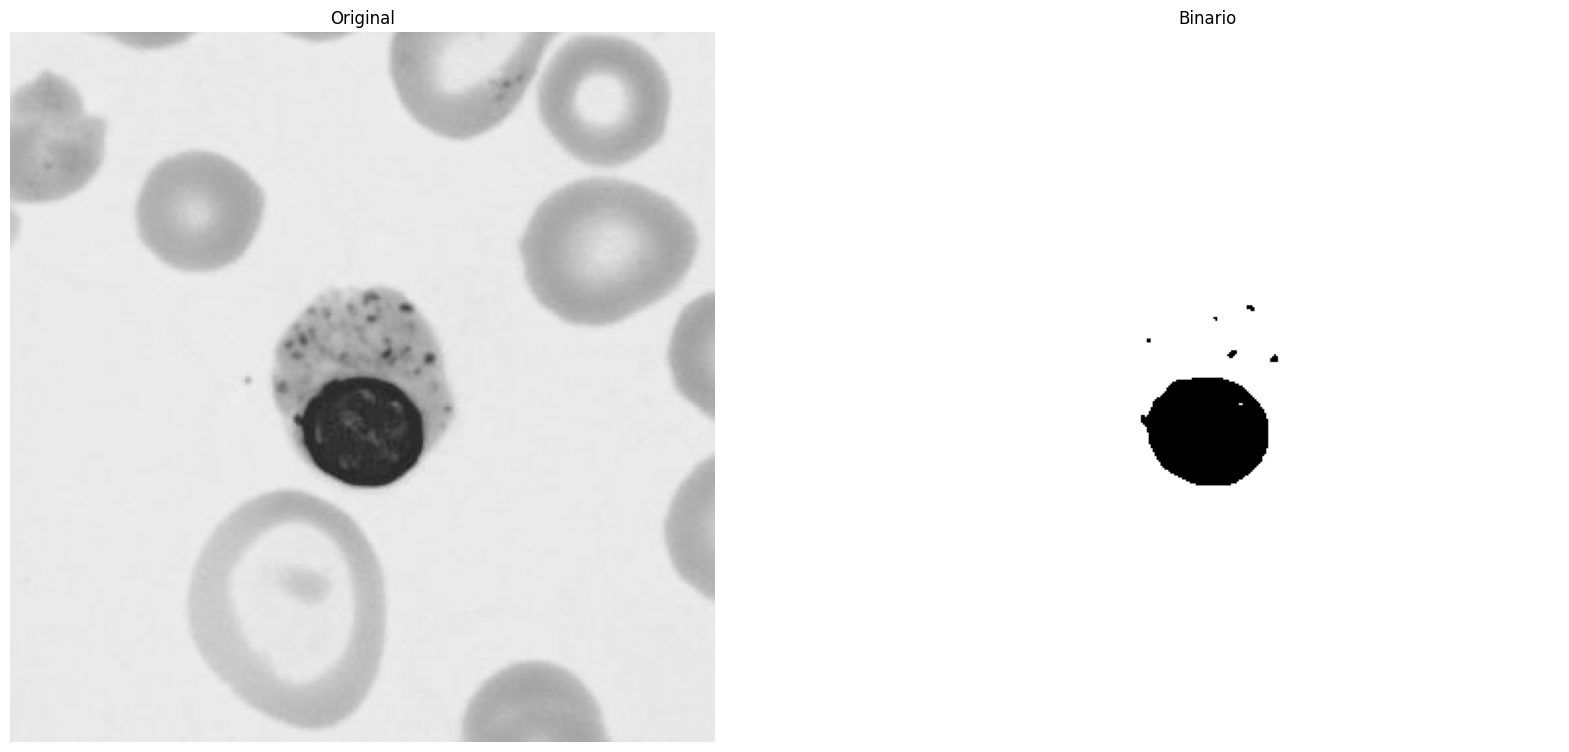

In [ ]:
# Umbralizacion manual de la imagen de eritoblasto
u_e,th1_e = cv2.threshold(IEG_eri0,100,255,cv2.THRESH_BINARY)

plt.figure()
plt.figure(figsize=(20,20))

plt.subplot(1,2,1)
plt.imshow(IEG_eri0,'gray',vmin=0,vmax=255)
plt.axis('off')
plt.title('Original')
plt.xticks([]),plt.yticks([])

plt.subplot(1,2,2)
plt.imshow(th1_e,'gray',vmin=0,vmax=255)
plt.axis('off')
plt.title('Binario')
plt.xticks([]),plt.yticks([])

print(u_e)

In [ ]:
def extraer_caracteristicas(i):
    # Convertimos la imagen a escala de grises
    gris = cv2.cvtColor(i, cv2.COLOR_BGR2GRAY)

    # Realizamos la umbralizacion
    u , th = cv2.threshold(gris, 100, 255, cv2.THRESH_BINARY)

    # Area Pixeles Blancos
    area = cv2.countNonZero(th)

    # Media de intensidades en escala de grises
    m_gris = np.mean(gris)

    return area, m_gris

In [ ]:
datos = []

# Basofilos
for nombre in basofilos.keys():
    img = cv2.imread(nombre)
    caracteristicas = extraer_caracteristicas(img)
    datos.append([*caracteristicas, 0]) # Clase 0 para Basofilos


# eritoblastos
for nombre in erito.keys():
    img = cv2.imread(nombre)
    caracteristicas = extraer_caracteristicas(img)
    datos.append([*caracteristicas, 1]) # Clase 1 para Eritoblastos

# creación DataFrame
columnas = ['Área', 'Media_Gris', 'Clase']
df = pd.DataFrame(datos, columns=columnas)

# Mostrar primeras filas
df.head()

,Área,Media_Gris,Clase
0,121327,197.566957,0
1,123567,196.410828,0
2,118973,178.919200,0
3,121684,196.349594,0
4,122496,198.594253,0


In [ ]:
df.to_csv('data_celulas.csv', index=False)
files.download('data_celulas.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>